## Exploratory Data Analysis (EDA) of Lumbar vertebral body and intervertebral disc segmentation in multi-scanner and multi-modal MRI – a ground truth database 

### Dataset overview

The database, accessible via the OSF Repository online, includes various segmentation files, and metadata detailing patient characteristics, pulse sequences, and MRI systems used (identifier: https://doi.org/10.17605/OSF.IO/QX5RT).

The imaging datasets feature non-contrast-enhanced and contrast-enhanced T1-weighted, T2-weighted, STIR, and specific T2-weighted DIXON sequences as separate datasets per patient scanner model. Segmentation maps for each vertebra (L1 to L5) and intervertebral discs (L1/2 to L4/5) are provided in *.nii format, aligned with the NIfTI standard, which facilitates easy handling in various programming environments like Python, Matlab, and R, and supports visualization with tools such as ImageJ and ITK-SNAP. 

Patient datasets and segmentation masks share the same ID, with vertebrae labeled L1 to L5 and intervertebral discs labeled L1_2 to L4_5.

### EDA

In [1]:
import os
import numpy as np
import pandas as pd
import pydicom
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

In [2]:
OSF_META_CSV = "data/osf-metadata/metadata_extracted.csv"
OSF_IMG_ROOT = "data/osf-files"

In [3]:
osf_df = pd.read_csv(OSF_META_CSV)

print("OSF metadata shape:", osf_df.shape)
print("Columns:", list(osf_df.columns))

OSF metadata shape: (34, 5)
Columns: ['ID', 'Gender', 'Age', 'Clinical Indication', 'Clinical Indication Code']


In [4]:
ID_COL = "ID"

osf_records = []
genders = []
ages = []  # years
manufacturers = []
manufacturer_models = []
image_shapes = []    # (x, y, z)
voxel_spacings = []  # (sx, sy, sz)

In [5]:
def find_nifti_images_for_id(subject_id):

    id_dir = f"ID{str(subject_id).zfill(2)}"
    root = os.path.join(OSF_IMG_ROOT, id_dir)
    if not os.path.isdir(root):
        return []

    found = []

    for manu_model in os.listdir(root):
        manu_model_path = os.path.join(root, manu_model)
        images_dir = os.path.join(manu_model_path, "Images")
        if not os.path.isdir(images_dir):
            continue
        for fname in os.listdir(images_dir):
            if fname.lower().find("t2") != -1 and fname.lower().endswith((".nii", ".nii.gz")):
                found.append(os.path.join(images_dir, fname))
    return found


def parse_age_from_meta(row):
  
    if "Age" in row and pd.notna(row["Age"]):
        try:
            return float(row["Age"])
        except Exception:
            return None
    return None


def safe_load_nifti(path):
    
    # First try: nibabel
    try:
        img = nib.load(path)
        data = img.get_fdata()
        shape = data.shape
        spatial_shape = shape[:3] if len(shape) >= 3 else shape
        zooms = img.header.get_zooms()
        if len(zooms) >= 3:
            sx, sy, sz = zooms[:3]
        else:
            sx = sy = sz = None
        return data, (sx, sy, sz), spatial_shape
    except Exception:
        pass

    # fail: SimpleITK
    try:
        sitk_img = sitk.ReadImage(path)
        arr_zyx = sitk.GetArrayFromImage(sitk_img)
        sz, sy, sx = sitk_img.GetSpacing()
        
        spatial_shape = (arr_zyx.shape[2], arr_zyx.shape[1], arr_zyx.shape[0]) 
        spacing_xyz = (sx, sy, sz)

        data_xyz = np.transpose(arr_zyx, (2, 1, 0))
        return data_xyz, spacing_xyz, spatial_shape

    except Exception as e:
        raise e

invalid_nifti_paths = []

for idx, row in osf_df.iterrows():
    subject_id = row[ID_COL]
    img_paths = find_nifti_images_for_id(subject_id)
    if not img_paths:
        continue

    for img_path in img_paths:
        try:
            data, (sx, sy, sz), spatial_shape = safe_load_nifti(img_path)
        except Exception as e:
            print(f"Failed to read NIfTI {img_path}: {e}")
            invalid_nifti_paths.append((img_path, str(e)))
            continue


        parts = os.path.normpath(img_path).split(os.sep)
        manu = "Unknown"
        manu_model = "Unknown"

        for i, p in enumerate(parts):
            if p.startswith("ID") and i + 1 < len(parts):
                manu_model_full = parts[i + 1]  
                if "_" in manu_model_full:
                    manu, model = manu_model_full.split("_", 1)
                else:
                    manu, model = manu_model_full, ""
                manu_model = model if model else manu_model_full
                break

        sex = row.get("Gender", "Unknown")
        if pd.isna(sex) or str(sex).strip() == "":
            sex = "Unknown"
        age_years = parse_age_from_meta(row)

        genders.append(sex)
        ages.append(age_years)
        manufacturers.append(manu)
        manufacturer_models.append(manu_model)
        image_shapes.append(spatial_shape)
        voxel_spacings.append((sx, sy, sz))

        osf_records.append({
            "id": subject_id,
            "path": img_path,
            "sex": sex,
            "age_years": age_years,
            "manufacturer": manu,
            "manufacturer_model": manu_model,
            "shape_xyz": spatial_shape,
            "spacing_xyz": (sx, sy, sz),
        })

print(f"\nTotal OSF images read (nibabel or SimpleITK): {len(osf_records)}")
print(f"Total invalid / non-readable T2 files skipped: {len(invalid_nifti_paths)}")

# gender distribution
gender_counts = Counter(genders)
total_cases = sum(gender_counts.values())
print("\nOSF gender distribution:")
for g, c in gender_counts.items():
    frac = c / total_cases if total_cases > 0 else 0
    print(f"  {g}: {c} ({frac:.2%})")

# age statistics
valid_ages = [a for a in ages if a is not None]
if valid_ages:
    age_array = np.array(valid_ages, dtype=float)
    print("\nAge (years):")
    print(f"  Count with age: {len(valid_ages)}")
    print(f"  Mean: {age_array.mean():.1f}")
    print(f"  Std : {age_array.std(ddof=0):.1f}")
    print(f"  Min : {age_array.min():.1f}")
    print(f"  Max : {age_array.max():.1f}")
else:
    print("\nNo valid age information available in OSF metadata.")

# manufacturer / model stats
manu_counts = Counter(manufacturers)
model_counts = Counter(manufacturer_models)

print("\nManufacturer distribution:")
for m, c in manu_counts.items():
    frac = c / len(manufacturers) if manufacturers else 0
    print(f"  {m}: {c} ({frac:.2%})")

print("\nManufacturerModelName distribution:")
for m, c in model_counts.items():
    frac = c / len(manufacturer_models) if manufacturer_models else 0
    print(f"  {m}: {c} ({frac:.2%})")

# shape statistics
if image_shapes:
    shapes_array = np.array(image_shapes, dtype=float)
    mean_x = shapes_array[:, 0].mean()
    mean_y = shapes_array[:, 1].mean()
    mean_z = shapes_array[:, 2].mean()
    unique_shapes = {tuple(s) for s in image_shapes}
    print("\nImage shape (x, y, z):")
    print(f"  Mean size: {mean_x:.1f} x {mean_y:.1f} x {mean_z:.1f}")
    print(f"  Unique shapes: {unique_shapes}")
else:
    print("\nNo shapes collected for OSF dataset.")

# spacing statistics
valid_spacings = [ps for ps in voxel_spacings if all(v is not None for v in ps)]
if valid_spacings:
    ps_array = np.array(valid_spacings, dtype=float)   # (n, 3) [sx, sy, sz]
    mean_sx = ps_array[:, 0].mean()
    mean_sy = ps_array[:, 1].mean()
    mean_sz = ps_array[:, 2].mean()
    print("\nVoxel spacing (mm) (sx, sy, sz):")
    print(f"  Mean: {mean_sx:.4f} x {mean_sy:.4f} x {mean_sz:.4f}")
    print(f"  Unique spacings: {set(tuple(np.round(ps, 4)) for ps in ps_array)}")
else:
    print("\nNo valid spacing information found in OSF images.")


Total OSF images read (nibabel or SimpleITK): 51
Total invalid / non-readable T2 files skipped: 0

OSF gender distribution:
  Female: 30 (58.82%)
  Male: 21 (41.18%)

Age (years):
  Count with age: 51
  Mean: 63.2
  Std : 15.2
  Min : 30.0
  Max : 88.1

Manufacturer distribution:
  Philips: 36 (70.59%)
  Siemens: 14 (27.45%)
  GE: 1 (1.96%)

ManufacturerModelName distribution:
  Achieva: 27 (52.94%)
  Verio: 4 (7.84%)
  Avanto: 5 (9.80%)
  Ingenia: 4 (7.84%)
  Symphony: 1 (1.96%)
  Elition: 4 (7.84%)
  Amira: 1 (1.96%)
  Espree: 1 (1.96%)
  Aera: 1 (1.96%)
  Magnetom: 1 (1.96%)
  Achieva_external: 1 (1.96%)
  Signa: 1 (1.96%)

Image shape (x, y, z):
  Mean size: 676.1 x 675.1 x 16.8
  Unique shapes: {(704, 704, 15), (704, 704, 21), (512, 512, 14), (448, 448, 18), (1200, 1200, 17), (896, 896, 15), (1120, 1120, 19), (384, 384, 11), (640, 640, 18), (384, 384, 14), (576, 576, 18), (640, 640, 21), (384, 384, 17), (704, 704, 17), (640, 640, 27), (320, 320, 15), (320, 320, 21), (720, 720, 15

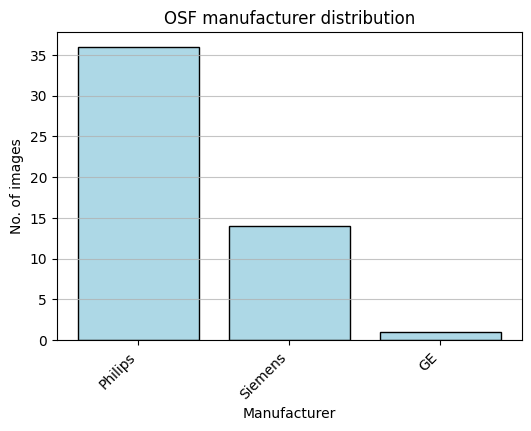

In [ ]:
# histogram of manufacturer

manufacturer_counts = Counter(manufacturers)
labels = list(manufacturer_counts.keys())
sizes = list(manufacturer_counts.values())
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color='lightblue', edgecolor='black')
plt.title('OSF manufacturer distribution')
plt.xlabel('Manufacturer')
plt.ylabel('No. of images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.show() 

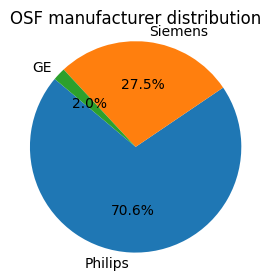

In [8]:
# pie chart of manufacturer

labels = list(manufacturer_counts.keys())
sizes = manufacturer_counts.values()
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)   
plt.title('OSF manufacturer distribution')
plt.axis('equal')

plt.show()

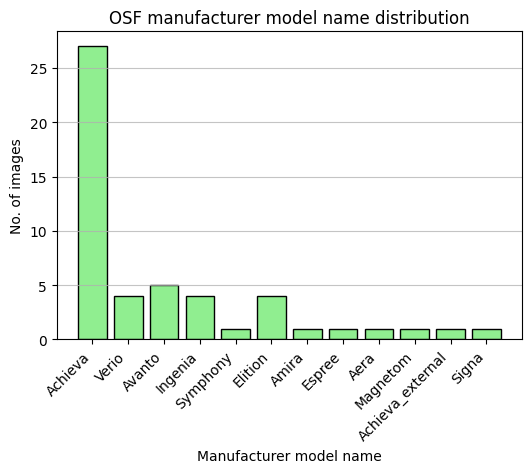

In [11]:
# histogram of manufacturer model names

model_name_counts = Counter(manufacturer_models)
labels = list(model_name_counts.keys())
sizes = list(model_name_counts.values())
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color='lightgreen', edgecolor='black')
plt.title('OSF manufacturer model name distribution')       
plt.xlabel('Manufacturer model name')
plt.ylabel('No. of images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.show()  

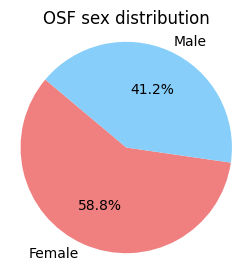

In [12]:
# sex pie chart

labels = ["Female", "Male"]
labels = gender_counts.keys()
sizes = gender_counts.values()
plt.figure(figsize=(3, 3)) 
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'lightskyblue', 'lightgreen']) 
plt.title('OSF sex distribution')
plt.axis('equal')

plt.show()

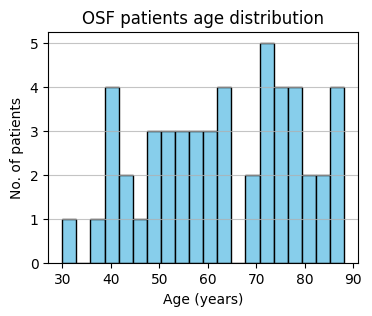

In [16]:
# age histogram

if valid_ages:
    plt.figure(figsize=(4, 3))
    plt.hist(age_array, bins=20, color='skyblue', edgecolor='black')
    plt.title('OSF patients age distribution')
    plt.xlabel('Age (years)')
    plt.ylabel('No. of patients')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

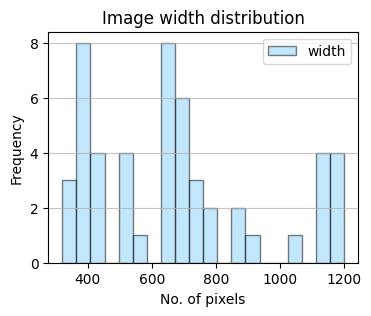

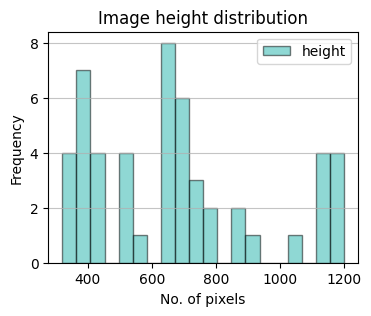

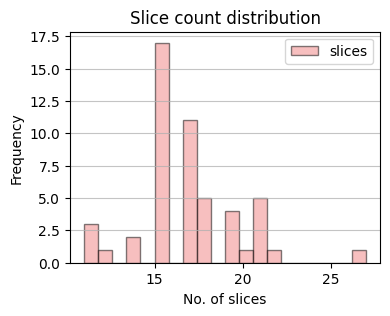

In [15]:
# histogram of image size

shapes_array = np.array(image_shapes)
xs = shapes_array[:, 0]
ys = shapes_array[:, 1]
zs = shapes_array[:, 2]
plt.figure(figsize=(4, 3))
plt.hist(xs, bins=20, alpha=0.5, label='width', color='lightskyblue', edgecolor='black')
plt.title('Image width distribution')
plt.xlabel('No. of pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()  

plt.figure(figsize=(4, 3))
plt.hist(ys, bins=20, alpha=0.5, label='height', color='lightseagreen', edgecolor='black')
plt.title('Image height distribution')
plt.xlabel('No. of pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()  

plt.figure(figsize=(4, 3))
plt.hist(zs, bins=20, alpha=0.5, label='slices', color='lightcoral', edgecolor='black')
plt.title('Slice count distribution')
plt.xlabel('No. of slices')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()  

### NIfTI visualization (slices analysis)

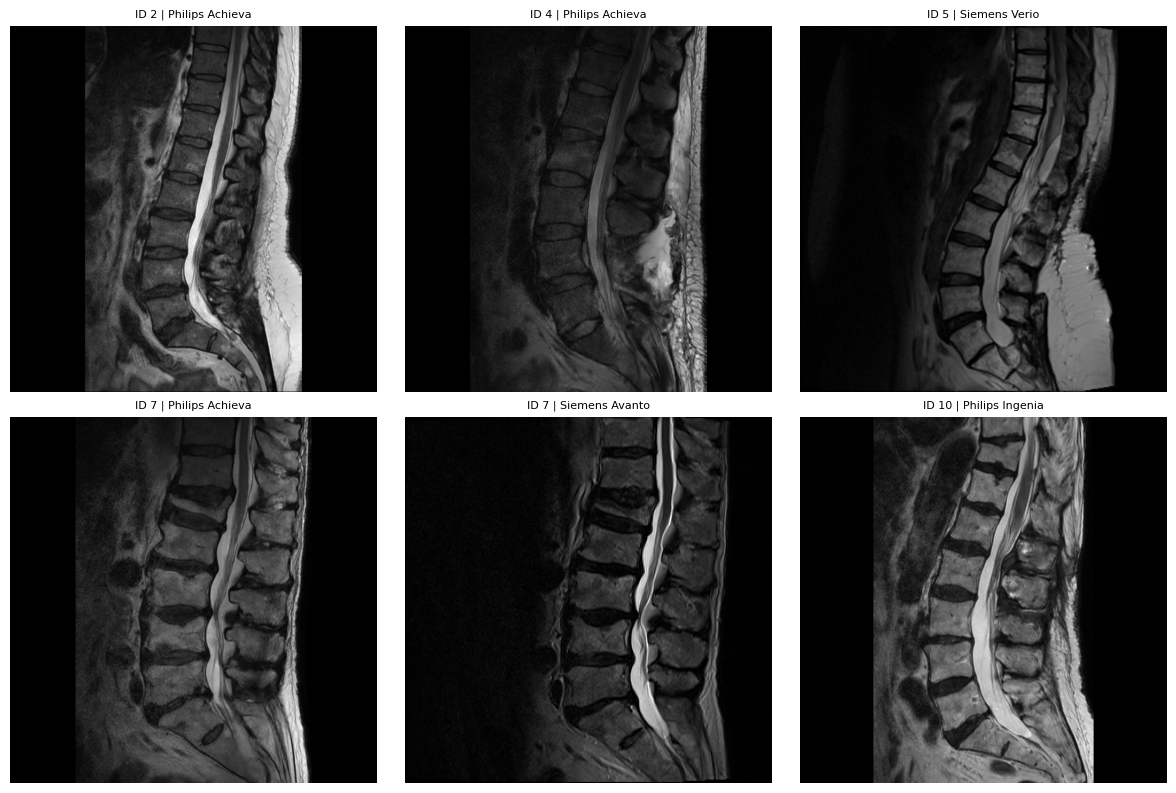

In [27]:
def show_middle_slices_osf(records, max_cases=6, figsize=(12, 8)):
 
    n = min(len(records), max_cases)
    if n == 0:
        print("No OSF records available.")
        return

    cols = 3
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, rec in zip(axes, records[:n]):
        data, _, spatial_shape = safe_load_nifti(rec["path"])
       
        x, y, z = spatial_shape
        mid = z // 2
        slice_xy = data[:, :, mid]

        ax.imshow(slice_xy.T, cmap="gray", origin="lower")
        title = f"ID {rec['id']} | {rec['manufacturer']} {rec['manufacturer_model']}"
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_middle_slices_osf(osf_records, max_cases=6)